# 🪰 ffbf - Novelty Detection on a Semantic Stream

The **Fruit Fly Bloom Filter** answers one question, continuously, over an endless stream:

> *"Have I recently seen anything **like** this?"*

Not "is this exact item in my set" - that is a classic Bloom filter. This one **generalises**
(a never-seen sentence from a familiar domain is already half-known), it **forgets**
(what stops arriving becomes new again), and it does both in **fixed memory**: a few thousand
floats, whatever the stream length.

This notebook puts it on real sentence embeddings, in three acts:

| Act | What happens | What to watch |
|---|---|---|
| **I** | 20 tech sentences arrive | novelty collapses - the domain is learned |
| **II** | one cuisine sentence slips in | novelty spikes - never seen anything like it |
| **III** | 25 cuisine sentences, with `tick()` | the map flips: cuisine becomes normal, tech turns new again |

## 1 - Setup

In [1]:
# %pip install sentence-transformers umap-learn matplotlib  # uncomment if needed

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import umap
from sentence_transformers import SentenceTransformer

from ffbf import FFBF, FFBFConfig, DecayMode, TickShape
from ffbf.viz import (
    PALETTE,
    apply_style,
    novelty_cmap,
    plot_novelty_scores,
    plot_novelty_map,
    plot_weight_map,
    plot_weight_evolution,
    plot_embedding_3d,
)

apply_style()
model = SentenceTransformer("all-MiniLM-L6-v2")

/home/barr/Documents/Projects/ffbf-noelty-detector/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10968.42it/s]

### Hyperparameters

The defaults are deliberately conservative. This demo wants a **sensitive** filter, so three
knobs are pushed: a hard depression (`delta`), an almost silent passive recovery (`epsilon`),
and a very sparse projection. `epsilon` is the one that matters most - it restores every
*inactive* synapse on each `add()`, so a large value erases the memory as fast as it is written.

In [ ]:
cfg = FFBFConfig.default_for(input_dim=384, expected_n=50)
cfg.m = 1200                    #Kenyon cells; the whole memory is m floats
cfg.k = 20                      #winners per input (1.7% of m) - the sparse tag of an input
cfg.projection_sparsity = 0.01  #each KC samples ~4 of the 384 embedding dimensions
cfg.delta = 0.9                 #depression of the winners on add() - hard, so one pass is enough
cfg.epsilon = 0.002             #recovery of the losers on add() - near-silent, so memory persists
cfg.decay_mode = DecayMode.EdgeAndFront
cfg.tick_shape = TickShape.Log
cfg.tick_rate = 0.06            #forgetting speed applied by tick() - calibrated so Act III swaps the two domains
cfg.window_size = 20            #baseline length behind the adaptive is_novel() threshold
cfg.seed = 42

f = FFBF(cfg)
print(f"Memory: {cfg.m} synapses = {cfg.m * 4 / 1024:.1f} KiB - constant, whatever the stream length")

Memory: 1200 synapses = 4.7 KiB — constant, whatever the stream length


In [4]:
def novelty_of(filt: FFBF, embeddings: np.ndarray) -> np.ndarray:
    """Novelty of every embedding under the current filter state, without modifying it.
    Parameters:
        filt (FFBF): filter to probe
        embeddings (np.ndarray): shape (n, input_dim) matrix of inputs
    Returns:
        np.ndarray: shape (n,) novelty scores, 1.0 = never seen anything like it
    """
    return np.array([filt.novelty(v) for v in embeddings])


def running_baseline(scores: list[float], window: int) -> np.ndarray:
    """Mean of the last `window` scores at each step, mirroring the filter's internal NoveltyWindow.
    This is the moving reference is_novel() compares against, recomputed here only to plot it.
    Parameters:
        scores (list[float]): novelty score at each step
        window (int): number of past scores kept in the baseline
    Returns:
        np.ndarray: shape (len(scores),) baseline, NaN at the first step where no history exists
    """
    return np.array([
        np.mean(scores[max(0, i - window):i]) if i else np.nan
        for i in range(len(scores))
    ])

## 2 - Corpus & map

25 tech sentences and 25 cuisine sentences. Five tech sentences are **held out** of the
stream - they are never fed to the filter, and serve later to prove it generalises rather
than memorises.

UMAP gives us a 2D map of the embedding space: the two axes are **semantic directions**, so
two nearby points are two sentences that mean similar things. **The filter never sees these
coordinates** - they exist only so we can watch, point by point, what it considers familiar.

> **How to read every map below.** Position = meaning, and it never changes. **Novelty is the
> colour, and only the colour** - the light-to-dark scale on the right, never a coordinate.
> What moves from one map to the next is the shade of the points, not their place.

In [5]:
TECH = ['GPUs are essential for training deep neural networks.', "Rust's borrow checker prevents data races at compile time.", 'Transformers revolutionized natural language processing.', 'A Bloom filter tests set membership with probabilistic guarantees.', "Moore's law describes the doubling of transistor density roughly every two years.", 'Kubernetes orchestrates containerized workloads across clusters.', 'Gradient descent minimizes a loss function by following the negative gradient.', 'Version control enables collaborative software development through branching.', 'The Linux kernel is written primarily in C and assembly.', 'Attention mechanisms allow models to focus on relevant input tokens.', 'Sparse random projections preserve pairwise distances in high-dimensional space.', 'TCP provides reliable, ordered delivery of bytes over IP networks.', 'A hash function maps arbitrary data to fixed-size digest values.', 'JIT compilation translates bytecode to native machine instructions at runtime.', 'Convolutional neural networks exploit spatial locality in image data.', 'Database indexing trades write overhead for faster read queries.', 'Backpropagation computes gradients via the chain rule of calculus.', 'WebAssembly enables near-native performance in web browsers.', 'The CAP theorem states distributed systems cannot guarantee consistency, availability, and partition tolerance simultaneously.', 'Embeddings map discrete tokens to dense continuous vector representations.', 'Memory-mapped files allow treating disk regions as in-process virtual memory.', 'Quantization reduces model size by lowering floating-point precision.', 'Asymptotic analysis describes algorithm complexity as input size grows.', 'SIMD instructions process multiple data elements in a single CPU clock cycle.', 'Reinforcement learning agents maximize cumulative reward through trial and error.']

CUISINE = ['Al dente pasta requires well-salted boiling water.', 'Maillard reaction gives browned food its distinctive flavor.', 'Mise en place means having all ingredients prepped before cooking begins.', 'Tempering chocolate aligns cocoa butter crystals for a glossy snap.', 'Emulsification binds fat and water with the help of a lecithin-rich emulsifier.', 'A roux of equal parts butter and flour thickens sauces and soups.', 'Deglazing a pan with wine dissolves the caramelized fond into a sauce.', 'Blanching vegetables preserves color and texture before freezing.', 'Fermentation by lactic acid bacteria transforms milk into yogurt.', 'Braising cooks tough cuts of meat low and slow in a small amount of liquid.', 'Umami is the savory taste associated with glutamate-rich ingredients.', 'Sous vide cooking seals food in a bag and cooks it in a temperature-controlled water bath.', 'Reduction concentrates flavor by boiling off liquid from a sauce.', 'Caramelization occurs when sugars are heated above 160°C.', 'A beurre blanc sauce is an emulsion of butter, white wine, and shallots.', 'Fresh herbs added at the end of cooking preserve volatile aromatic compounds.', 'Salt draws moisture from ingredients through osmosis.', 'Stock is made by simmering bones and aromatics to extract collagen and flavor.', 'Kneading dough develops gluten networks that trap carbon dioxide from yeast.', 'Scoring bread before baking controls oven spring and crust expansion.', 'Fat-soluble vitamins in vegetables are better absorbed when cooked with oil.', 'Dry brining meat with salt draws out moisture that is then reabsorbed.', 'Acid from lemon juice or vinegar brightens flavors and balances richness.', 'Mirepoix is a base of diced onion, carrot, and celery used in French cooking.', 'Rest time after roasting allows muscle fibers to relax and reabsorb juices.']

In [ ]:
tech_emb = model.encode(TECH, convert_to_numpy=True).astype(np.float32)
cuisine_emb = model.encode(CUISINE, convert_to_numpy=True).astype(np.float32)
all_emb = np.vstack([tech_emb, cuisine_emb])
DOMAINS: list[str] = ["Tech"] * len(TECH) + ["Cuisine"] * len(CUISINE)

tech_stream = tech_emb[:20]   #fed to the filter during Act I
tech_holdout = tech_emb[20:]  #never fed - the generalisation probe

#cosine matches how the embeddings were trained; a large n_neighbors on such a small corpus
#keeps the global layout readable instead of collapsing each domain into a dot
coords = umap.UMAP(
    n_components=2,
    n_neighbors=25,
    min_dist=0.6,
    spread=1.5,
    metric="cosine",
    random_state=42,
).fit_transform(all_emb)
print(f"Tech {tech_emb.shape}, Cuisine {cuisine_emb.shape} -> map {coords.shape}")

/home/barr/Documents/Projects/ffbf-noelty-detector/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Tech (25, 384), Cuisine (25, 384) -> map (50, 2)


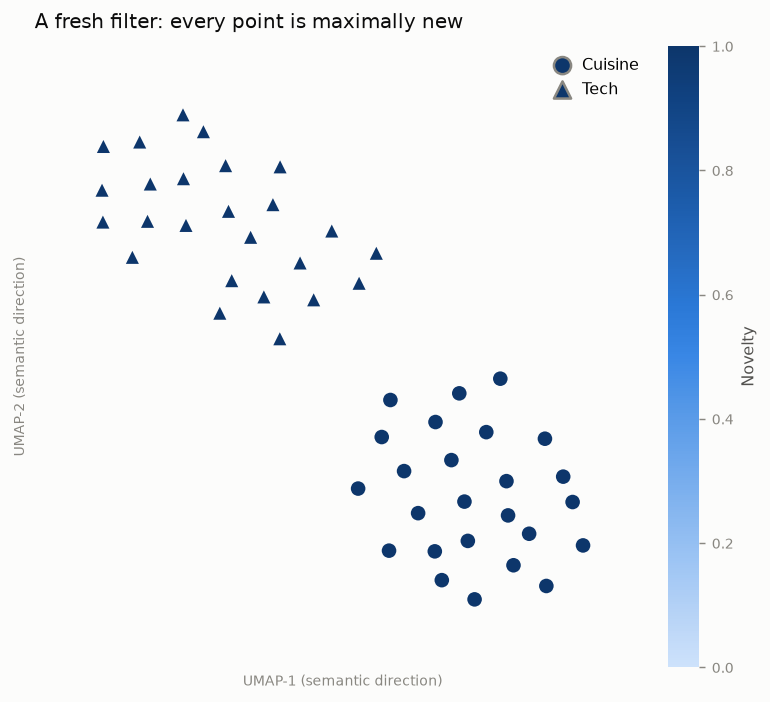

In [7]:
#every point is at 1.0 here, so the uniform shade is the baseline the next maps depart from
fig, ax = plt.subplots(figsize=(7.5, 5.5))
plot_novelty_map(
    coords,
    novelty_of(f, all_emb),
    domains=DOMAINS,
    title="A fresh filter: every point is maximally new",
    axis_labels=("UMAP-1 (semantic direction)", "UMAP-2 (semantic direction)"),
    ax=ax,
)
plt.tight_layout()
plt.show()

The same 50 points under a plain PCA, in 3D. It answers a different question from the map above:
**is the tech/cuisine split real in the raw embedding space, or an artefact of UMAP?**

PCA only rotates the space onto its axes of greatest variance - it invents nothing. Seeing the
two domains separate here means the structure is genuinely in the embeddings, so what the
filter will exploit is real and not a projection artefact. Marker size is novelty, uniform at
this point since nothing has been learned.

That separation is all the filter has to work with: it has no labels, no distance metric and
stores no vector - only `k` winning synapses per input.

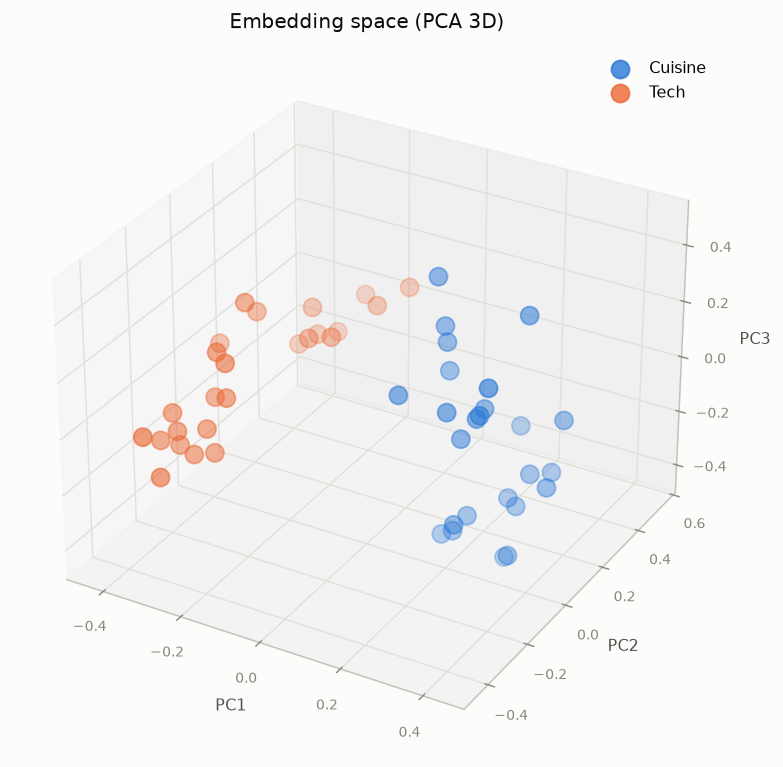

In [8]:
fig = plt.figure(figsize=(7.5, 6))
ax_3d = fig.add_subplot(projection="3d")
plot_embedding_3d(all_emb, DOMAINS, list(novelty_of(f, all_emb)), ax=ax_3d)
plt.tight_layout()
plt.show()

## 3 - Act I: learning the tech domain

20 sentences arrive one at a time. Each is scored **before** being learned, so the curve is an
honest online measurement: what the filter thought right before it knew.

This is the regime a monitor actually runs in - one pass, no second look, decide now - and the
dashed baseline is what `is_novel()` compares against, so no fixed threshold has to be chosen
in advance.

In [9]:
weights_fresh = f.weights().copy()
scores_I: list[float] = []
for vec in tech_stream:
    scores_I.append(f.novelty(vec))  #score it before learning it
    f.add(vec)
weights_after_I = f.weights().copy()
map_after_I = novelty_of(f, all_emb)

print(f"First sentence: {scores_I[0]:.2f}   last sentence: {scores_I[-1]:.2f}")

First sentence: 1.00   last sentence: 0.68


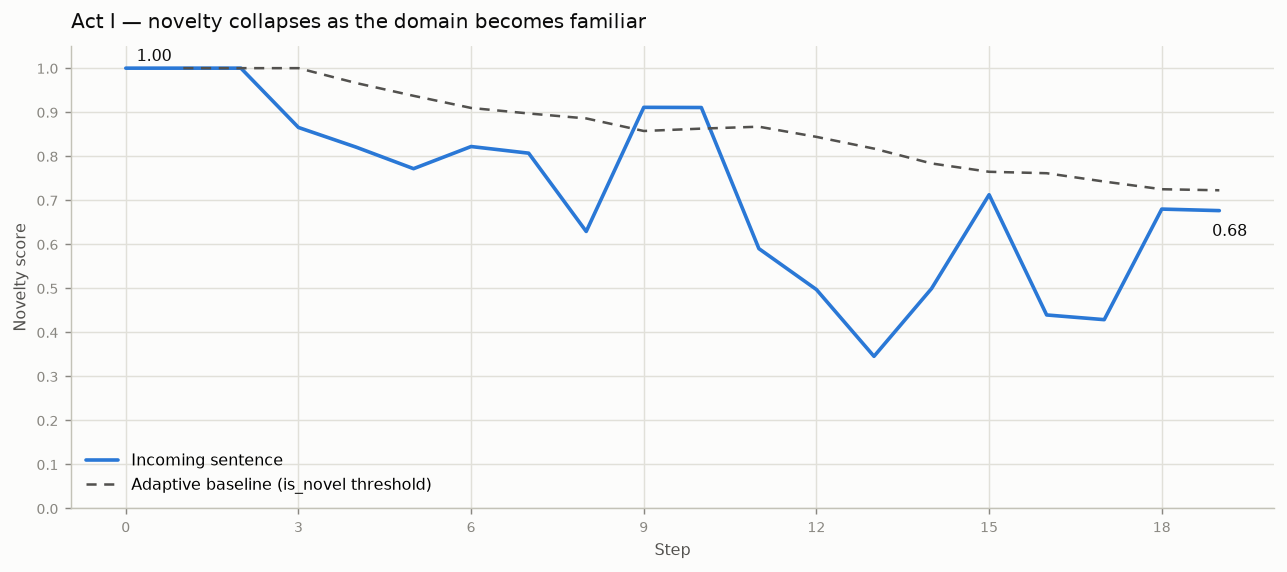

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4.5))
plot_novelty_scores(scores_I, label="Incoming sentence", ax=ax)
ax.plot(
    running_baseline(scores_I, cfg.window_size),
    color=PALETTE["ink_soft"], linewidth=1.4, linestyle=(0, (4, 3)),
    label="Adaptive baseline (is_novel threshold)",
)
ax.legend(loc="lower left")
ax.set_title("Act I - novelty collapses as the domain becomes familiar")
#direct-label the two endpoints only; the axis carries the rest
ax.annotate(f"{scores_I[0]:.2f}", (0, scores_I[0]), textcoords="offset points",
            xytext=(6, 4), color=PALETTE["ink"], fontsize=9)
ax.annotate(f"{scores_I[-1]:.2f}", (len(scores_I) - 1, scores_I[-1]), textcoords="offset points",
            xytext=(-4, -14), color=PALETTE["ink"], fontsize=9)
plt.tight_layout()
plt.show()

The memory itself, one cell per Kenyon cell. Dark = untouched (still reads as new), light = depressed by what has been learned. Only a small fraction of the 1200 synapses carries the whole tech domain - that sparsity is what keeps the filter cheap and composable.

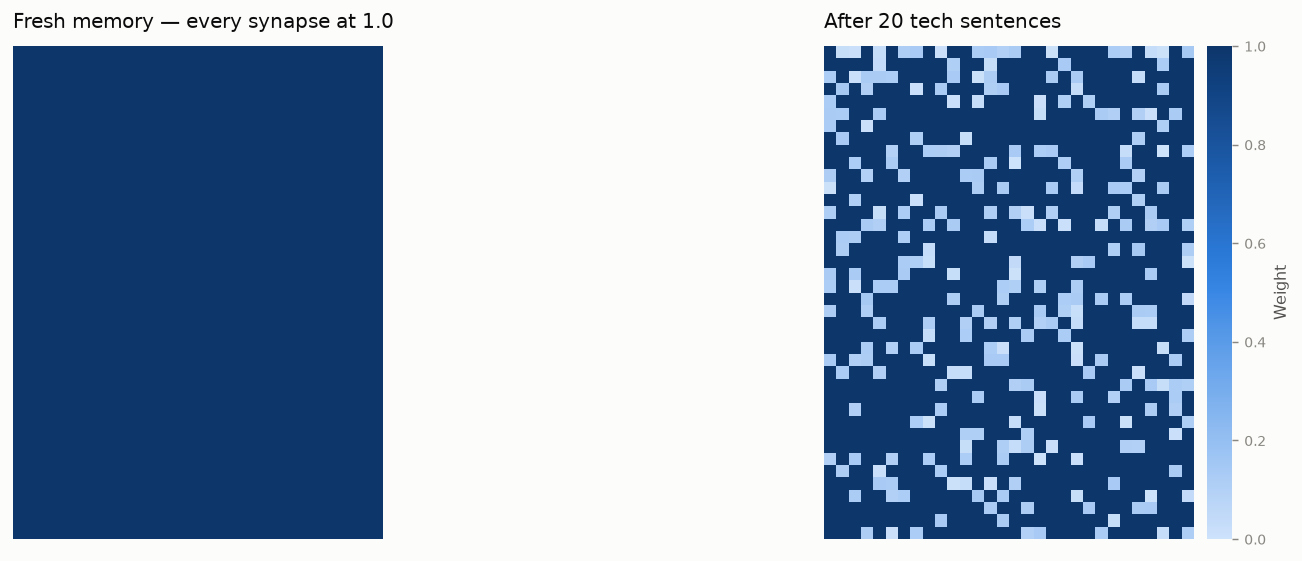

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), layout="constrained")
plot_weight_map(weights_fresh, title="Fresh memory - every synapse at 1.0", ax=axes[0], colorbar=False)
plot_weight_map(weights_after_I, title="After 20 tech sentences", ax=axes[1])
plt.show()

## 4 - Act II: the intruder

One cuisine sentence arrives. Nothing tells the filter it changed domain - no label, no
threshold tuned by hand. The comparison that matters is three-way, and it is the whole point
of the filter.

In [12]:
spike_sentence = "Les pâtes al dente nécessitent une eau bien salée."
vec_spike = model.encode([spike_sentence], convert_to_numpy=True)[0].astype(np.float32)
score_spike = float(f.novelty(vec_spike))  #observed only, not learned

levels: dict[str, float] = {
    "Sentence it already learned": float(novelty_of(f, tech_stream).mean()),
    "Unseen tech sentence": float(novelty_of(f, tech_holdout).mean()),
    "Cuisine intruder": score_spike,
}
for name, value in levels.items():
    print(f"{name:<28} {value:.2f}  {'█' * round(value * 30)}")

Sentence it already learned  0.07  ██
Unseen tech sentence         0.45  ██████████████
Cuisine intruder             0.81  ████████████████████████


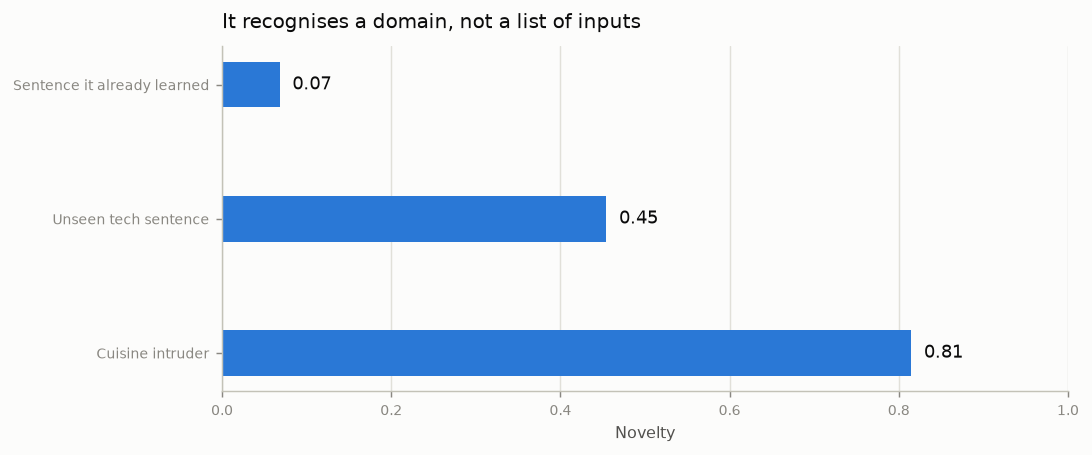

In [13]:
fig, ax = plt.subplots(figsize=(8.5, 3.6))
names = list(levels)
values = [levels[n] for n in names]
ax.barh(names, values, color=PALETTE["series_1"], height=0.34)
for name, value in zip(names, values):
    ax.text(value + 0.015, name, f"{value:.2f}", va="center", color=PALETTE["ink"], fontsize=10)
ax.set_xlim(0, 1)
ax.set_xlabel("Novelty")
ax.invert_yaxis()
ax.grid(axis="y", visible=False)
ax.set_title("It recognises a domain, not a list of inputs")
plt.tight_layout()
plt.show()

Three levels, one filter, no supervision:

- a sentence it learned is **familiar** - that much a hash set could do;
- a tech sentence it has *never seen* sits **halfway** - this is generalisation, and it is
  what a Bloom filter cannot do;
- the cuisine sentence is **new** - the spike a monitor would alert on.

## 5 - Act III: drift and forgetting

25 cuisine sentences now arrive, each followed by `tick()`. `add()` writes, `tick()` forgets:
every synapse creeps back toward 1.0, so whatever stops arriving slowly becomes new again.
A twin filter runs the same stream **without** `tick()`, to isolate what forgetting buys.

In [14]:
f_notick = FFBF(cfg)  #same seed, same projection: the only difference is that it never forgets
for vec in tech_stream:
    f_notick.add(vec)

scores_III: list[float] = []
scores_III_notick: list[float] = []
tech_curve: list[float] = []          #how new the tech domain looks, step by step
cuisine_curve: list[float] = []
tech_curve_notick: list[float] = []
weight_history: list[np.ndarray] = []
map_mid: np.ndarray = np.zeros(len(all_emb))

for step, vec in enumerate(cuisine_emb):
    scores_III.append(f.novelty(vec))
    f.add(vec)
    f.tick()
    scores_III_notick.append(f_notick.novelty(vec))
    f_notick.add(vec)

    tech_curve.append(float(novelty_of(f, tech_stream).mean()))
    cuisine_curve.append(float(novelty_of(f, cuisine_emb).mean()))
    tech_curve_notick.append(float(novelty_of(f_notick, tech_stream).mean()))
    weight_history.append(f.weights().copy())
    if step == 11:
        map_mid = novelty_of(f, all_emb)

map_after_III = novelty_of(f, all_emb)
weights_after_III = f.weights().copy()
weight_history_arr = np.stack(weight_history)  #shape (25, m)
print(f"Tech domain: {tech_curve[0]:.2f} at the start of Act III -> {tech_curve[-1]:.2f} at the end")

Tech domain: 0.12 at the start of Act III -> 0.73 at the end


### The map over time

Same 50 points, same coordinates, four moments - only the shading changes.

Panel ② is the one that matters: the **whole** tech region goes pale, including the five
sentences never fed to the filter. Familiarity spreads by meaning, not by item, which is what
lets the filter cover a domain it has only partly seen. Panel ④ shows the same mechanism
running backwards as the region darkens again.

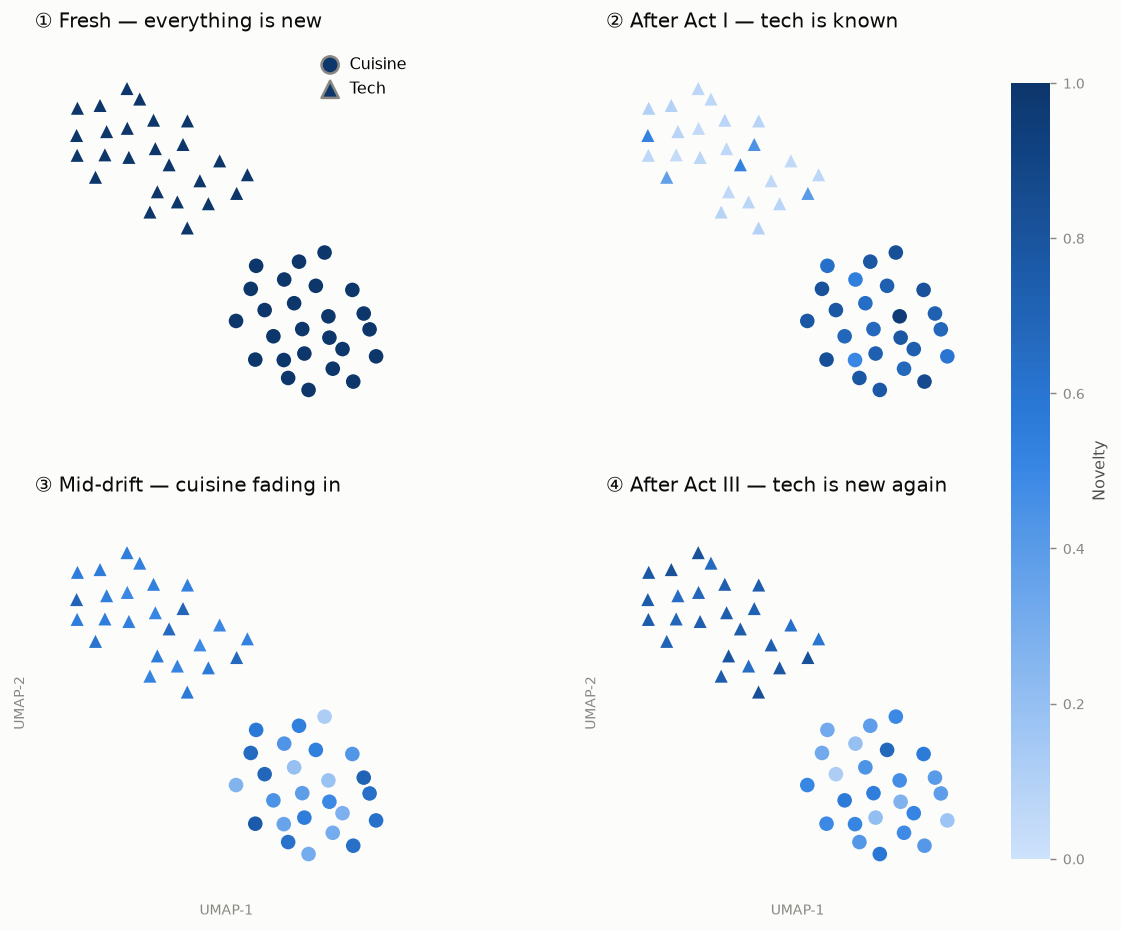

In [ ]:
snapshots: list[tuple[str, np.ndarray]] = [
    ("① Fresh - everything is new", novelty_of(FFBF(cfg), all_emb)),
    ("② After Act I - tech is known", map_after_I),
    ("③ Mid-drift - cuisine fading in", map_mid),
    ("④ After Act III - tech is new again", map_after_III),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))
for i, (ax, (title, snapshot)) in enumerate(zip(axes.flat, snapshots)):
    #the shape legend is identical on all four panels, so only the first carries it
    plot_novelty_map(
        coords, snapshot, domains=DOMAINS, title=title, ax=ax,
        colorbar=False, legend=i == 0,
        #axes named on the bottom row only: the reminder is useful, four times is noise
        axis_labels=("UMAP-1", "UMAP-2") if i >= 2 else None,
    )
#one shared scale for the four panels rather than four identical colorbars
mappable = plt.cm.ScalarMappable(cmap=novelty_cmap(), norm=plt.Normalize(0.0, 1.0))
bar = fig.colorbar(mappable, ax=axes, fraction=0.035, pad=0.02)
bar.set_label("Novelty", color=PALETTE["ink_soft"], fontsize=9)
bar.outline.set_visible(False)
bar.ax.tick_params(color=PALETTE["muted"], labelcolor=PALETTE["muted"], labelsize=8)
plt.show()

### The stream, end to end

The intruder is marked in orange. It does not tower over the curve, and that is the honest
result: it sits above the recent baseline, not above everything - which is exactly the
comparison `is_novel()` makes, and why a drifting stream needs a moving reference rather than
a constant.

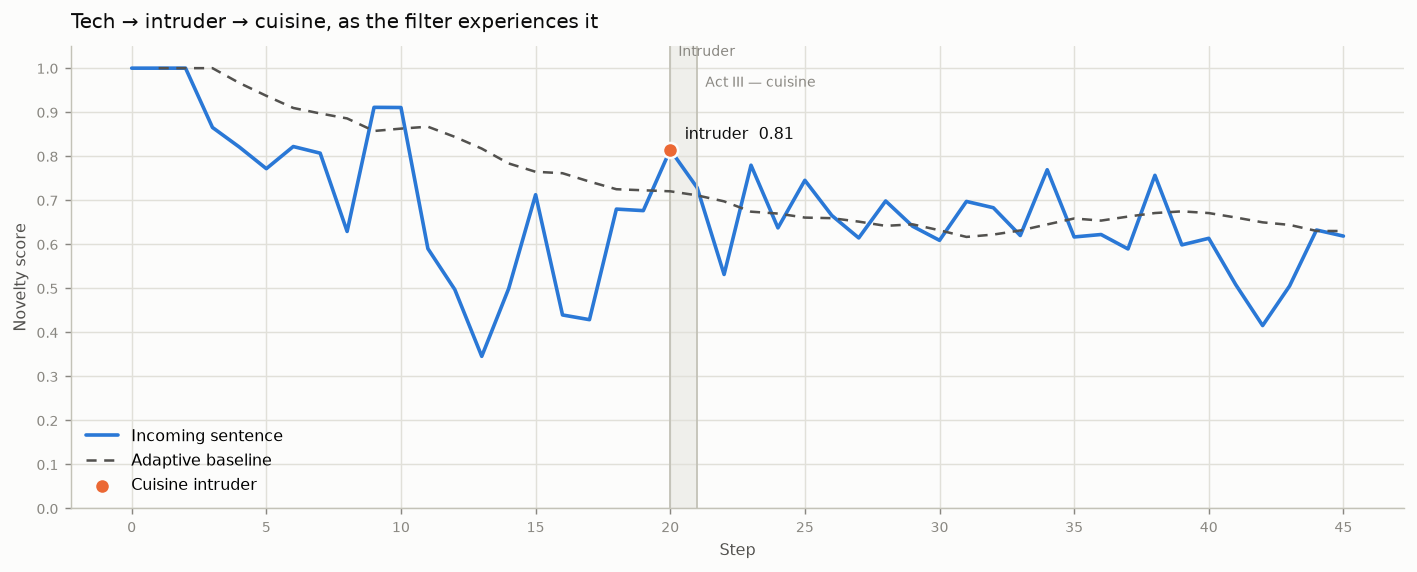

In [ ]:
scores_all = scores_I + [score_spike] + scores_III
fig, ax = plt.subplots(figsize=(11, 4.5))
plot_novelty_scores(
    scores_all,
    phases=[(len(scores_I), "Intruder"), (len(scores_I) + 1, "Act III - cuisine")],
    label="Incoming sentence",
    ax=ax,
)
ax.plot(
    running_baseline(scores_all, cfg.window_size),
    color=PALETTE["ink_soft"], linewidth=1.4, linestyle=(0, (4, 3)),
    label="Adaptive baseline",
)
ax.scatter(
    [len(scores_I)], [score_spike], s=70, zorder=3, color=PALETTE["series_2"],
    linewidths=1.4, edgecolors=PALETTE["surface"], label="Cuisine intruder",
)
ax.legend(loc="lower left")
ax.set_title("Tech → intruder → cuisine, as the filter experiences it")
ax.annotate(
    f"intruder  {score_spike:.2f}",
    (len(scores_I), score_spike), textcoords="offset points", xytext=(8, 6),
    color=PALETTE["ink"], fontsize=9,
)
plt.tight_layout()
plt.show()

### Forgetting, measured

Instead of the incoming sentence, we now probe the **two whole corpora** at every step. Neither curve is fed back into the filter - they are pure measurements of what it currently knows.

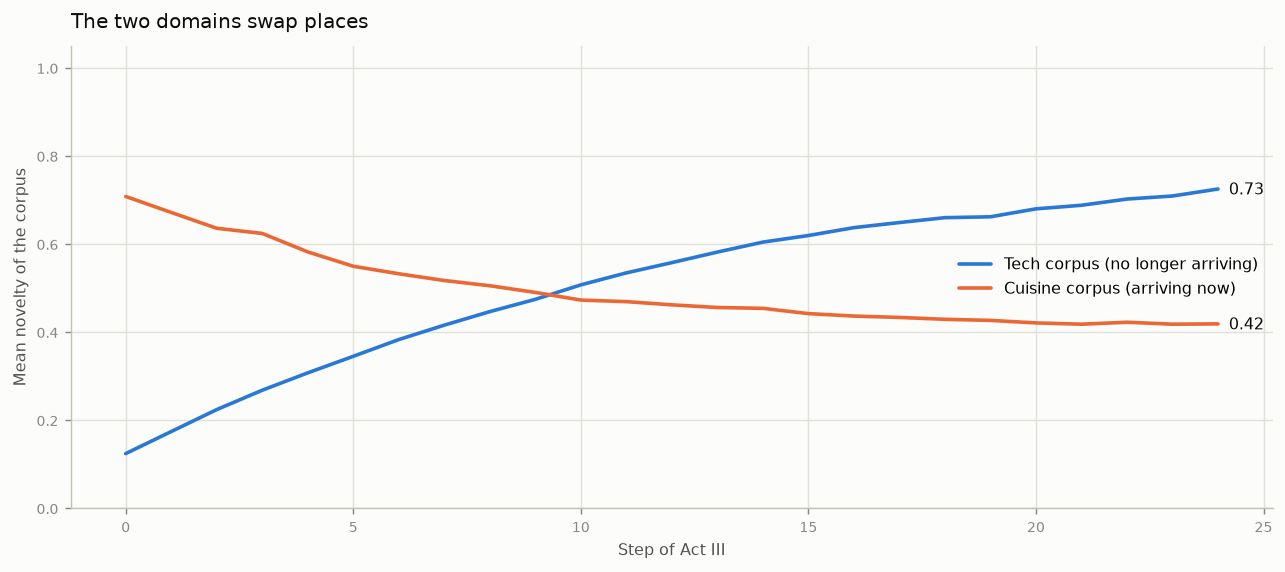

In [17]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(tech_curve, color=PALETTE["series_1"], label="Tech corpus (no longer arriving)")
ax.plot(cuisine_curve, color=PALETTE["series_2"], label="Cuisine corpus (arriving now)")
ax.set_xlabel("Step of Act III")
ax.set_ylabel("Mean novelty of the corpus")
ax.set_ylim(0, 1.05)
ax.legend(loc="center right")
ax.set_title("The two domains swap places")
#direct-label both ends; placement carries identity, so the text stays ink-colored
for curve in (tech_curve, cuisine_curve):
    ax.annotate(f"{curve[-1]:.2f}", (len(curve) - 1, curve[-1]), textcoords="offset points",
                xytext=(6, -3), color=PALETTE["ink"], fontsize=9)
plt.tight_layout()
plt.show()

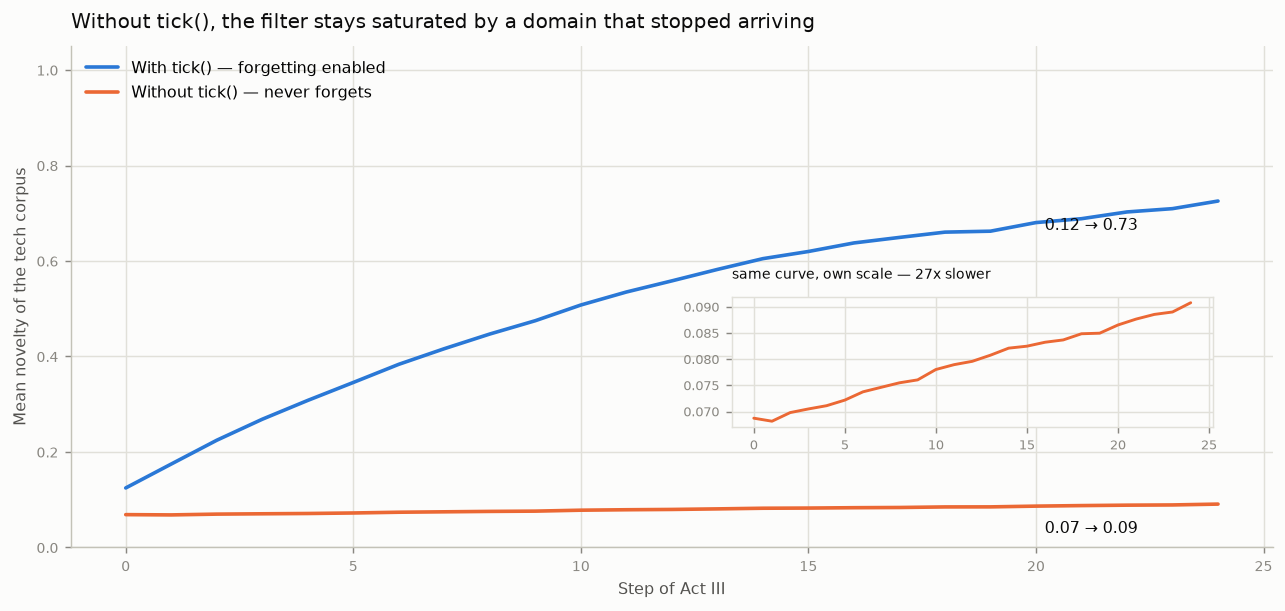

In [ ]:
gain_tick = tech_curve[-1] - tech_curve[0]
gain_notick = tech_curve_notick[-1] - tech_curve_notick[0]

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(tech_curve, color=PALETTE["series_1"], label="With tick() - forgetting enabled")
ax.plot(tech_curve_notick, color=PALETTE["series_2"], label="Without tick() - never forgets")
ax.set_xlabel("Step of Act III")
ax.set_ylabel("Mean novelty of the tech corpus")
ax.set_ylim(0, 1.05)
ax.legend(loc="upper left")
ax.set_title("Without tick(), the filter stays saturated by a domain that stopped arriving")
for curve in (tech_curve, tech_curve_notick):
    ax.annotate(f"{curve[0]:.2f} → {curve[-1]:.2f}", (len(curve) - 1, curve[-1]),
                textcoords="offset points", xytext=(-96, -16), color=PALETTE["ink"], fontsize=9)

#the lower curve is not flat, it is 30x slower: an inset with its own scale shows its real shape
inset = ax.inset_axes([0.55, 0.24, 0.40, 0.26])
inset.plot(tech_curve_notick, color=PALETTE["series_2"], linewidth=1.6)
inset.set_title(f"same curve, own scale - {gain_tick / gain_notick:.0f}x slower", fontsize=8)
inset.tick_params(labelsize=7)
#a hairline box marks it as an inset rather than a second series on the main axes
for spine in inset.spines.values():
    spine.set_visible(True)
    spine.set_color(PALETTE["grid"])
plt.tight_layout()
plt.show()

This is the practical difference with a classic Bloom filter: bits only ever get set, so it saturates and its false-positive rate climbs forever. Here the memory is bounded **and** self-clearing, which is what makes it usable on an endless stream.

### Inside the memory

The right panel below follows individual synapses through Act III, which is where the two
opposite forces become visible one at a time.

Each **vertical drop** is an `add()` in which that synapse was among the `k` winners: its weight
is multiplied by `1 - delta`, so a single occurrence writes the memory almost completely.
Each **slow climb** is `tick()` pulling it back toward 1.0 - that climb *is* the forgetting, and
its steepness is how fast this memory would vanish if the input never came back.

The spacing of the teeth therefore measures how often that semantic feature recurs in the
stream, and the height reached between two drops measures how much was forgotten in between.
A synapse that climbs for a long time before its first drop is one whose feature only appears
late in the stream.

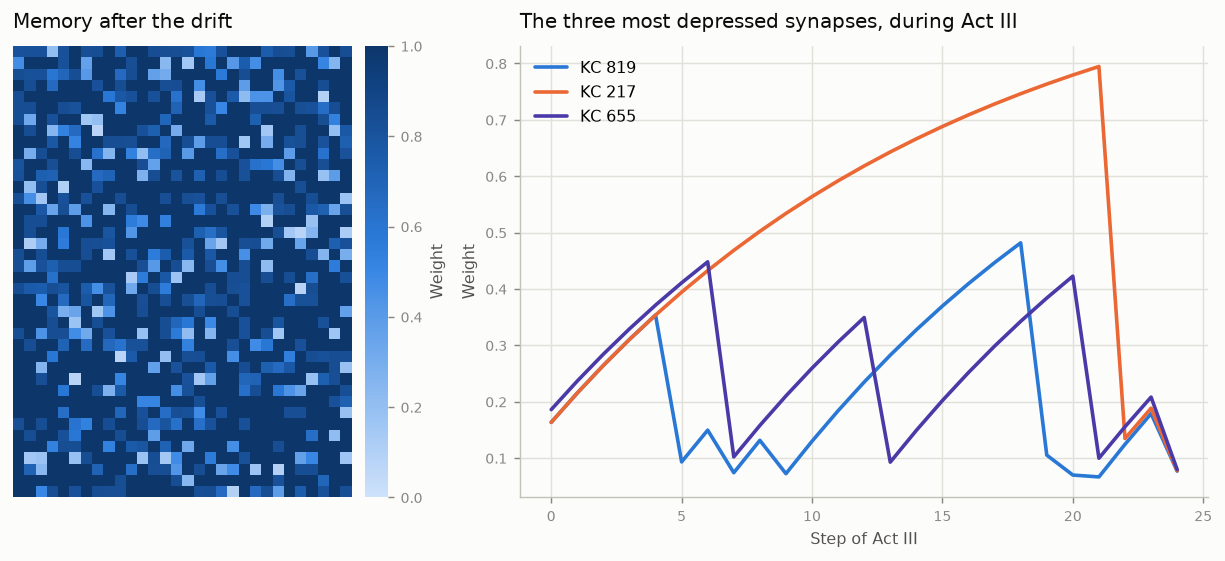

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), layout="constrained")
plot_weight_map(weights_after_III, title="Memory after the drift", ax=axes[0])
#follow the synapses the cuisine phase depressed the most, not arbitrary indices;
#three of them, because that is how many hues stay separable
busiest = list(np.argsort(weights_after_III)[:3])
plot_weight_evolution(weight_history_arr, indices=busiest, ax=axes[1])
axes[1].set_title("The three most depressed synapses, during Act III")
axes[1].set_xlabel("Step of Act III")
plt.show()

## 6 - Parameter exploration

Each subsection replays the whole scenario with one knob changed, everything else fixed.

In [ ]:
def run_scenario(override_cfg: FFBFConfig) -> tuple[list[float], list[float]]:
    """Replay the tech→cuisine stream on a fresh filter built from the given config.
    Parameters:
        override_cfg (FFBFConfig): configuration to test
    Returns:
        tuple[list[float], list[float]]: novelty scores for the tech phase, then the cuisine phase
    """
    flocal = FFBF(override_cfg)
    s_tech: list[float] = []
    for vec in tech_stream:
        s_tech.append(flocal.novelty(vec))
        flocal.add(vec)
    s_cuisine: list[float] = []
    for vec in cuisine_emb:
        s_cuisine.append(flocal.novelty(vec))
        flocal.add(vec)
        flocal.tick()
    return s_tech, s_cuisine


def tuned_cfg() -> FFBFConfig:
    """Copy of the notebook configuration, as the baseline every sweep starts from.
    Returns:
        FFBFConfig: the 1 configuration, ready to be overridden on one field
    """
    c = FFBFConfig.default_for(input_dim=384, expected_n=50)
    c.m, c.k, c.projection_sparsity = cfg.m, cfg.k, cfg.projection_sparsity
    c.delta, c.epsilon = cfg.delta, cfg.epsilon
    c.decay_mode, c.tick_shape, c.tick_rate = cfg.decay_mode, cfg.tick_shape, cfg.tick_rate
    c.window_size, c.seed = cfg.window_size, cfg.seed
    return c

### 6.1 `delta` - how hard one input is written

`delta` is the depression applied to the winning synapses. Low values need many repetitions before anything is learned; high values learn a domain in a single pass.

It is the knob for how much evidence counts as *seen*: raise it to react to one-shot events, lower it to stay indifferent until something actually repeats.

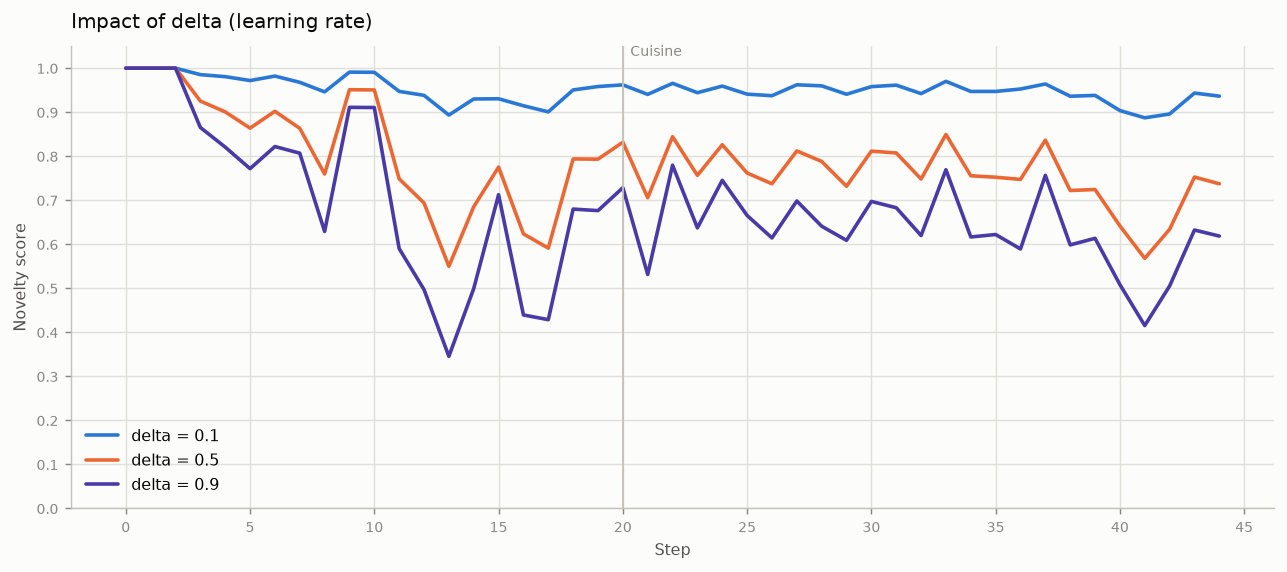

In [21]:
fig, ax = plt.subplots(figsize=(10, 4.5))
for d in (0.1, 0.5, 0.9):
    c = tuned_cfg()
    c.delta = d
    s_t, s_c = run_scenario(c)
    plot_novelty_scores(s_t + s_c, label=f"delta = {d}", ax=ax)
ax.axvline(x=len(tech_stream), color=PALETTE["axis"], linewidth=1)
ax.text(len(tech_stream) + 0.3, 1.02, "Cuisine", fontsize=8, color=PALETTE["muted"], va="bottom")
ax.set_title("Impact of delta (learning rate)")
plt.tight_layout()
plt.show()

### 6.2 `tick_shape` - the shape of forgetting

`tick()` pulls every weight back toward 1.0, and `tick_shape` sets **how that speed depends on
how old the memory already is** - whether a fresh trace fades at the same rate as one that has
nearly gone. That is what decides if the filter keeps a sharp short-term memory with a long
tail, or the opposite.

Reading it off the stream is unreliable, so the two panels below measure it at the source:
one synapse is depressed by a single input, then only `tick()` is called. The left panel is its
weight over time; the right one is the same data as **forgetting speed against current
weight**, which is the curve that actually defines each shape.

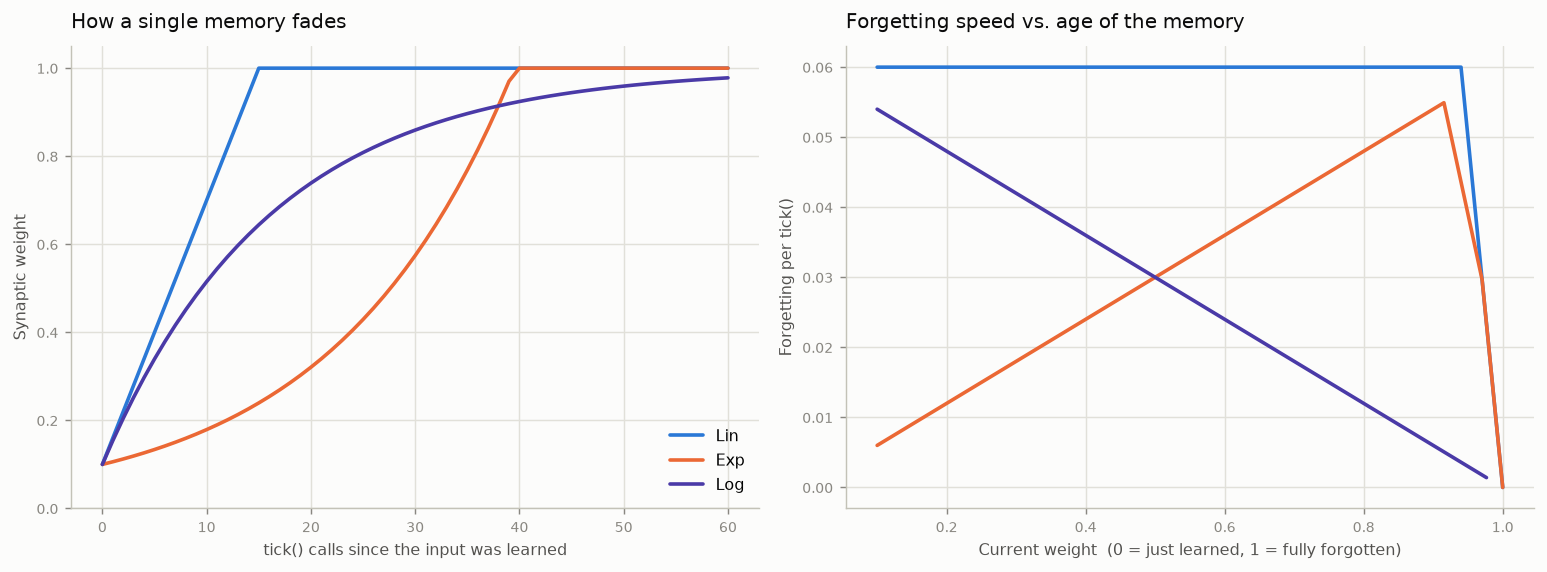

In [22]:
def recovery_curve(shape: TickShape, steps: int =60) -> np.ndarray:
    """Weight of a single depressed synapse across `steps` calls to tick().
    Isolates tick(): the synapse is depressed once, then nothing is added, and epsilon is
    disabled so the only force left is the passive decay under test.
    Parameters:
        shape (TickShape): decay curve to measure
        steps (int): number of tick() calls to trace
    Returns:
        np.ndarray: shape (steps + 1,) weight of the most depressed synapse, tick by tick
    """
    c = tuned_cfg()
    c.tick_shape = shape
    c.epsilon = 0.0
    probe = FFBF(c)
    probe.add(tech_stream[0])
    kc = int(np.argmin(probe.weights()))
    trace: list[float] = [float(probe.weights()[kc])]
    for _ in range(steps):
        probe.tick()
        trace.append(float(probe.weights()[kc]))
    return np.array(trace)


fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for shape, name in ((TickShape.Lin, "Lin"), (TickShape.Exp, "Exp"), (TickShape.Log, "Log")):
    trace = recovery_curve(shape)
    axes[0].plot(trace, label=name)
    #speed against state, not against time: this is the definition of each shape
    axes[1].plot(trace[:-1], np.diff(trace), label=name)
axes[0].set_xlabel("tick() calls since the input was learned")
axes[0].set_ylabel("Synaptic weight")
axes[0].set_ylim(0, 1.05)
axes[0].set_title("How a single memory fades")
axes[0].legend(loc="lower right")
axes[1].set_xlabel("Current weight  (0 = just learned, 1 = fully forgotten)")
axes[1].set_ylabel("Forgetting per tick()")
axes[1].set_title("Forgetting speed vs. age of the memory")
plt.tight_layout()
plt.show()

Read the right panel left to right: it is the speed of forgetting as a memory ages, and the
three shapes take three directions. `Lin` is **flat** - `tick_rate` per tick whatever the
synapse holds, so a trace goes from freshly learned to fully forgotten in `1 / tick_rate`
ticks, about 15 here. `Exp` **rises**: a fresh trace moves by 0.006 per tick against 0.055 for
an almost-forgotten one, so a memory is held nearly intact for a long while and then wiped in
a handful of ticks. `Log` **falls**, the mirror image: 0.054 on a fresh trace against 0.006 at
the top, so half the depression is undone in a dozen ticks and the rest trails off, never
quite reaching 1.0. The cliff at the right edge of `Lin` and `Exp` is only the clamp: the
last step is truncated so the weight lands on 1.0 instead of overshooting it.

This is the knob for choosing **what the filter should keep longest**: `Exp` protects the
recent and drops the stale, `Log` keeps a faint trace of everything for a long time, `Lin`
treats both alike. The demo runs on `Log` because it is the one that makes the drift readable
at this stream length - replayed on Act III at the same `tick_rate`, `Exp` only lifts the tech
corpus to 0.30 by the last sentence where `Log` reaches 0.73, so the domain swap would barely
show. The stream below is that comparison, one curve per shape.

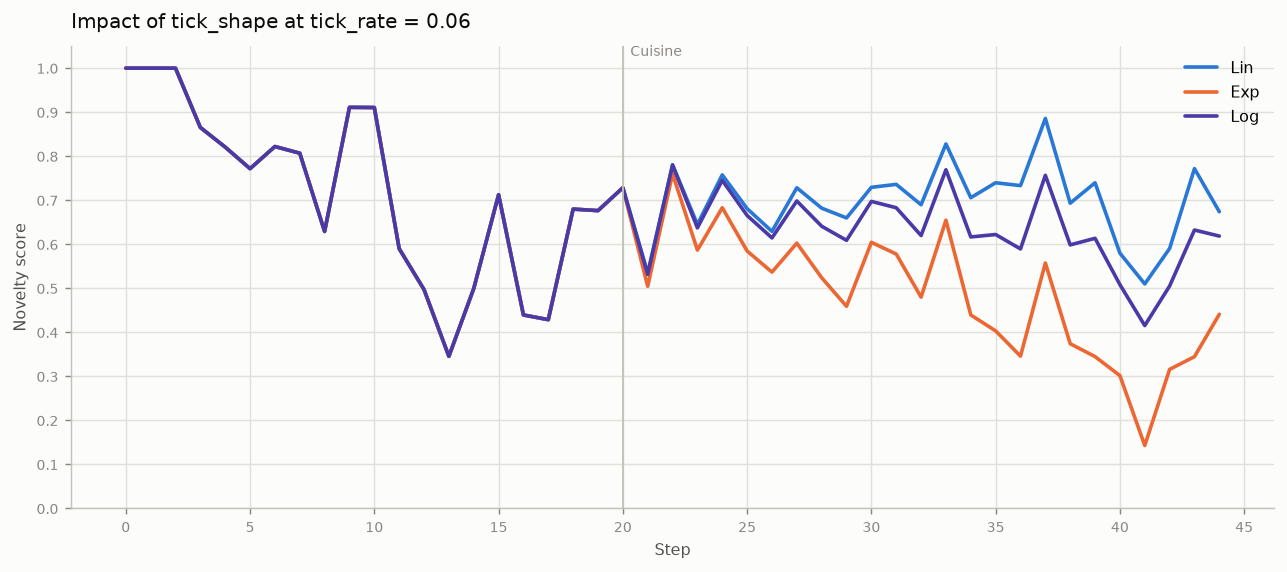

In [23]:
fig, ax = plt.subplots(figsize=(10, 4.5))
for shape, name in ((TickShape.Lin, "Lin"), (TickShape.Exp, "Exp"), (TickShape.Log, "Log")):
    c = tuned_cfg()
    c.tick_shape = shape
    s_t, s_c = run_scenario(c)
    plot_novelty_scores(s_t + s_c, label=name, ax=ax)
ax.axvline(x=len(tech_stream), color=PALETTE["axis"], linewidth=1)
ax.text(len(tech_stream) + 0.3, 1.02, "Cuisine", fontsize=8, color=PALETTE["muted"], va="bottom")
ax.set_title(f"Impact of tick_shape at tick_rate = {cfg.tick_rate:.2f}")
plt.tight_layout()
plt.show()

### 6.3 `window_size` - the adaptive threshold

`is_novel()` does not compare against a fixed value: it compares against the mean of the last `window_size` scores. A short window follows the stream closely and only flags sharp local jumps; a long one keeps a slower reference and stays sensitive to a sustained shift.

This sets the alert rate, and the flag count in each title is the practical trade-off: too short and the baseline chases the anomaly it should be detecting.

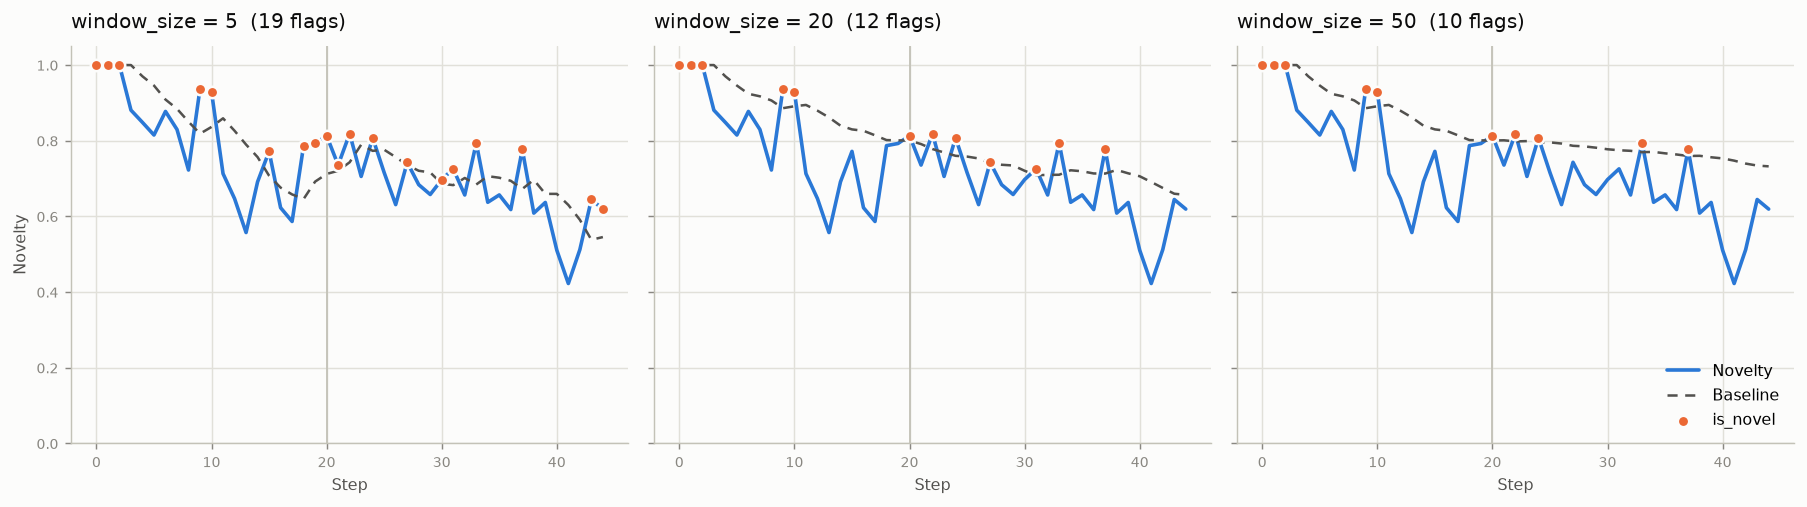

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, ws in zip(axes, (5, 20, 50)):
    c = tuned_cfg()
    c.window_size = ws
    flocal = FFBF(c)
    scores: list[float] = []
    flags: list[bool] = []
    for vec in np.vstack([tech_stream, cuisine_emb]):
        scores.append(flocal.novelty(vec))
        flags.append(flocal.is_novel(vec, threshold=1.0))
        flocal.add(vec)
        flocal.tick()
    flagged = [i for i, flag in enumerate(flags) if flag]
    ax.plot(scores, color=PALETTE["series_1"], label="Novelty")
    ax.plot(running_baseline(scores, ws), color=PALETTE["ink_soft"], linewidth=1.4,
            linestyle=(0, (4, 3)), label="Baseline")
    ax.scatter(flagged, [scores[i] for i in flagged], s=40, color=PALETTE["series_2"],
               zorder=3, linewidths=1.4, edgecolors=PALETTE["surface"], label="is_novel")
    ax.axvline(x=len(tech_stream), color=PALETTE["axis"], linewidth=1)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Step")
    ax.set_title(f"window_size = {ws}  ({len(flagged)} flags)")
axes[0].set_ylabel("Novelty")
axes[2].legend(loc="lower right")
plt.tight_layout()
plt.show()

## 7 - What to take away

- **Fixed memory.** 1200 floats hold a whole domain; nothing grows with the stream.
- **It generalises.** An unseen sentence from a known domain scores halfway, not "absent".
- **It forgets.** `tick()` returns the memory to the fresh state at a controlled pace, so a
  domain that stops arriving becomes detectable again - a Bloom filter can only saturate.
- **The threshold is adaptive.** `is_novel()` compares against a moving baseline, so no
  hand-tuned constant has to track the stream.

### Cleaning up memory after presentation

In [ ]:
import gc

#read the sizes before the names go, otherwise there is nothing left to measure
arrays: list[np.ndarray] = [
    all_emb, coords, weight_history_arr,
    weights_fresh, weights_after_I, weights_after_III,
    map_after_I, map_mid, map_after_III,
]
freed_mib: float = sum(a.nbytes for a in arrays) / 1024 ** 2
del arrays

#matplotlib keeps every figure in its registry until it is closed, inline display or not
plt.close("all")

#pop rather than del: the notebook stays re-runnable from any cell, and a name that was
#never created (a section skipped) is not an error here
dropped: int = 0
for name in (
    "model", "all_emb", "tech_emb", "cuisine_emb", "tech_stream", "tech_holdout",
    "vec_spike", "coords", "weight_history", "weight_history_arr", "weights_fresh",
    "weights_after_I", "weights_after_III", "map_after_I", "map_mid", "map_after_III",
    "snapshots", "f", "f_notick", "flocal", "trace", "levels", "scores_I", "scores_III",
    "scores_III_notick", "scores_all", "tech_curve", "tech_curve_notick", "cuisine_curve",
):
    dropped += globals().pop(name, None) is not None

collected: int = gc.collect()
print(f"Dropped {dropped} names, {freed_mib:.2f} MiB of arrays and the encoder " f"- {collected} objects reclaimed")

Dropped 29 names, 0.20 MiB of arrays and the encoder - 122403 objects reclaimed
